In [ ]:
import ast
import random

import pandas as pd
from sklearn.pipeline import make_pipeline
from statsmodels.sandbox.tools.cross_val import LeaveOneOut

In [ ]:
#df_arduino = pd.read_csv("../ArduinoApps/emg_auswertung/tsfel_debug.csv", index_col=0)
df_full = pd.read_csv("../auswertung_features/cache/feature_trim=0-minlen=0-win=0-step=50-fs=default_tsfel.csv", index_col=0)
df_expect = df_full.iloc[:,6:]

df_lorenzen = pd.read_csv("../auswertung_features/cache/feature_trim=0-minlen=0-win=0-step=50-fs=tsfel.csv", index_col=0)
a = df_lorenzen.filter(regex="^0_*", axis=1)
print(df_lorenzen.iloc[:,6:].shape, a.shape)

In [ ]:
# df_a: "normale" Spaltennamen
# df_b: hat ggf. "sensor_" als Präfix

# 1) Spalten von df_b normalisieren (nur wenn sie mit "sensor_" anfangen)
df_b_norm_cols = df_arduino.columns.str.replace(r"^sensor_", "", regex=True)

# Optional: Kopie mit umbenannten Spalten erstellen
df_b_norm = df_arduino.copy()
df_b_norm.columns = df_b_norm_cols

# 2) Vergleich: welche Spalten fehlen wo?
cols_a = set(df_expect.columns)
cols_b = set(df_b_norm.columns)

b = list(df_b_norm.columns)
count = 0
for i, column in  enumerate(df_expect.columns):
       if column != b[i]:
           print(column)
       else:
           count += 1
print(f"Anzahl an gleichen headern: {count}")
fehlen_in_b = sorted(cols_a - cols_b)  # in df_a vorhanden, aber nicht in df_b (nach Normalisierung)
fehlen_in_a = sorted(cols_b - cols_a)  # in df_b vorhanden, aber nicht in df_a

print("Fehlen in df_b:", fehlen_in_b)
print("Anzahl:", len(fehlen_in_b))
print("\n\nFehlen in df_a:", fehlen_in_a)
print("Anzahl:", len(fehlen_in_a))

# 3) (optional) Gemeinsame Spalten
gemeinsam = sorted(cols_a & cols_b)
print("\n\nGemeinsam:", gemeinsam)


# Test Model on Input again

In [ ]:
import pandas as pd
import numpy as np
from auswertung_features.build_features import split_into_label_blocks, load_session
from ArduinoApps.emg_auswertung.python.features import building_feature, block_to_win
from ANN.loso_windowed_blockfeat import compute_W_max, block_to_windows_postpad

# load dataset
session = load_session("../ArduinoApps/emg_messung/python/messdaten/messung_r_2.csv")
blocks = split_into_label_blocks(session)

test_block = blocks[1][0] # taking the 0 block

feats_df = building_feature(pd.DataFrame(test_block))
win = block_to_win(test_block, T = 500, stride = 250)

W_max = compute_W_max(2000, 500, 250)
X_ts_block, wlen, mask_block = block_to_win(test_block, T = 500, stride = 250, W_max=W_max)

In [ ]:
import tensorflow as tf
import pickle

tf_model = tf.keras.models.load_model("models/EMG-CNN-Model.keras")
scaler = pickle.load(open("models/scaler_features.pkl", "rb"))

X_feat = np.asarray(feats_df, dtype=np.float32)
X_feat = scaler.transform(X_feat).astype(np.float32)
X_feat3 = np.repeat(X_feat, repeats=win.shape[0], axis=0)  # (3, 624)

prob = tf_model.predict({"ts": win, "feat": X_feat3}, verbose=0)
y_pred = np.argmax(prob, axis=1)
print(y_pred)

In [ ]:
from ai_edge_litert.interpreter import Interpreter

lite_scaler =  pickle.load(open("models/scaler_features.pkl", "rb"))
tflite_model = Interpreter(model_path="models/EMG-CNN.tflite")
tflite_model.allocate_tensors()

in_details = tflite_model.get_input_details()
out_details = tflite_model.get_output_details()

N = win.shape[0]
X_feat = np.asarray(feats_df, dtype=np.float32)
X_feat = scaler.transform(X_feat).astype(np.float32)
#X_feat3 = np.repeat(X_feat, repeats=win.shape[0], axis=0)  # (3, 624)

probs = np.zeros((N, 5), dtype=np.float32)

for i in range(N):
    x_ts = win[i:i+1, :, :].astype(np.float32)       # (1,500,4)

    tflite_model.set_tensor(in_details[0]["index"], X_feat)    # (1,624)
    tflite_model.set_tensor(in_details[1]["index"], x_ts)      # (1,500,4)
    tflite_model.invoke()

    probs[i] = tflite_model.get_tensor(out_details[0]["index"])[0]  # (5,)

prob_block = probs.mean(axis=0)
print(int(np.argmax(prob_block)))

In [ ]:
import tensorflow as tf
import pickle

gru_model = tf.keras.models.load_model("models/EMG-GRU-Model.keras")
scaler_gru = pickle.load(open("models/scaler_features_GRU.pkl", "rb"))

X_feat = np.asarray(feats_df, dtype=np.float32)
X_feat = scaler_gru.transform(X_feat).astype(np.float32)

prob = gru_model.predict({"ts": X_ts_block, "feat": X_feat, "mask":mask_block}, verbose=0)
print(prob)
pred  = int(np.argmax(prob[0]))
print(pred)

# Testing Testing Testing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from auswertung_features.build_features import split_into_label_blocks, load_session
meta = pd.read_csv("../auswertung_features/meta.csv")
dict_blocks = {}
meta_blocks = {"subject_id":[], "hand": [], "rel_path":[], "block_id":[]}
for i, r in meta.iterrows():
    csv_path = r["rel_path"]
    df_session = load_session(csv_path)

    #Error Handling für leere dfs
    if df_session is None:
        continue

    blocks = split_into_label_blocks(df_session)
    for block in blocks:
        meta_blocks["subject_id"].append(r["subject_id"])
        meta_blocks["hand"].append(r["hand"])
        meta_blocks["rel_path"].append(r["rel_path"])
        meta_blocks["block_id"].append(len(dict_blocks))
        dict_blocks[len(dict_blocks)] = block
meta_blocks = pd.DataFrame(meta_blocks)
meta_blocks_r = meta_blocks[meta_blocks["hand"]=="r"].reset_index(drop=True)
meta_blocks_l = meta_blocks[meta_blocks["hand"]=="l"].reset_index(drop=True)

In [ ]:
from loso_windowed_blockfeat import block_to_windows_postpad
import tsfel
import os
feature_cache: dict[str, pd.DataFrame] = {}
def tsfel_feature_read(dict_blocks, tsfel_cfg, feature_set_name = "default_tsfel", fs = 500, b_pad = True):
    k = feature_set_name
    if b_pad:
        k = k + "_pad"
    feature_list = []
    if k not in feature_cache:
        if os.path.isfile(f"../auswertung_features/cache/feature_{k}.csv"):
            feature_cache[k] = pd.read_csv(f"../auswertung_features/cache/feature_{k}.csv", index_col=0)
        else:
            for win, label in dict_blocks.values():
                if b_pad:
                    X = block_to_windows_postpad(win, T=2000, stride=2000)
                else:
                    X = win
                feats_df= tsfel.time_series_features_extractor(tsfel_cfg, X, fs=fs)
                feature_list.append(feats_df.iloc[0].to_dict())
            feature_cache[k] = pd.DataFrame(feature_list)
            feature_cache[k].to_csv(f"../auswertung_features/cache/feature_{k}.csv")
    return feature_cache[k]

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
def logo_baseline(model, meta_block, dict_blocks, tsfel_cfg, feature_set_name= "default_tsfel", b_pad = True):
    logo = LeaveOneGroupOut()
    groups = meta_block["subject_id"].to_numpy()
    fold_metrics = []
    feat_global = tsfel_feature_read(dict_blocks, tsfel_cfg, feature_set_name= feature_set_name, b_pad=b_pad)
    for fold, (train_idx, val_idx) in enumerate(logo.split(meta_block, groups=groups)):
        y_list_tr = []
        y_list_va = []
        meta_tr = meta_block.iloc[train_idx].reset_index(drop=True)
        meta_va = meta_block.iloc[val_idx].reset_index(drop=True)

        #Xf_va = feat_global.loc[meta_va["block_id"].astype(int), feat_cols].to_numpy()
        for i, bid in enumerate(meta_tr["block_id"].to_numpy()):
            x_ts_raw, y_i = dict_blocks[int(bid)]
            y_list_tr.append(int(y_i))

        for i, bid in enumerate(meta_va["block_id"].to_numpy()):
            x_ts_raw, y_i = dict_blocks[int(bid)]
            y_list_va.append(int(y_i))

        y_tr = np.array(y_list_tr, dtype=np.int32)
        y_va = np.array(y_list_va, dtype=np.int32)

        X_all = feat_global
        X_tr = X_all.iloc[train_idx].reset_index(drop=True).to_numpy(np.float32)
        X_va = X_all.iloc[val_idx].reset_index(drop=True).to_numpy(np.float32)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)

        # Metrics
        acc = accuracy_score(y_va, y_pred)
        f1m = f1_score(y_va, y_pred, average="macro")
        cm = confusion_matrix(y_va, y_pred)

        # subject id in this fold is single subject
        subject_left_out = meta_va["subject_id"].unique()
        subject_left_out = int(subject_left_out[0]) if len(subject_left_out) == 1 else subject_left_out.tolist()

        fold_metrics.append({
            "fold": fold,
            "left_out_subject": subject_left_out,
            "n_val": len(y_va),
            "val_acc": float(acc),
            "val_macro_f1": float(f1m),
            "cm_pro_": cm,
        })

    return fold_metrics

In [ ]:
from sklearn.preprocessing import StandardScaler
import random

def logo_mlp(model, meta_block, dict_blocks, tsfel_cfg, feature_set_name = "default_tsfel", b_CNN = False, b_pad = True):
    logo = LeaveOneGroupOut()
    groups = meta_block["subject_id"].to_numpy()
    fold_metrics = []
    feat_global = tsfel_feature_read(dict_blocks, tsfel_cfg, feature_set_name= feature_set_name, b_pad=b_pad)

    for fold, (train_idx, val_idx) in enumerate(logo.split(meta_block, groups=groups)):
        y_list_tr = []
        y_list_va = []
        xts_list_tr = []
        xts_list_va = []
        meta_tr = meta_block.iloc[train_idx].reset_index(drop=True)
        meta_va = meta_block.iloc[val_idx].reset_index(drop=True)

        #Xf_va = feat_global.loc[meta_va["block_id"].astype(int), feat_cols].to_numpy()
        for i, bid in enumerate(meta_tr["block_id"].to_numpy()):
            x_tr_raw, y_i = dict_blocks[int(bid)]
            y_list_tr.append(int(y_i))
            #random.shuffle(y_list_tr) # used to test label leakage
            xts_list_tr.append(block_to_windows_postpad(x_tr_raw, T = 2000, stride=2000)[0])

        for i, bid in enumerate(meta_va["block_id"].to_numpy()):
            x_va_raw, y_i = dict_blocks[int(bid)]
            y_list_va.append(int(y_i))
            #random.shuffle(y_list_va)
            xts_list_va.append(block_to_windows_postpad(x_va_raw, T = 2000, stride=2000)[0])

        y_tr = np.array(y_list_tr, dtype=np.int32)
        y_va = np.array(y_list_va, dtype=np.int32)

        X_all = feat_global
        X_tr = X_all.iloc[train_idx].reset_index(drop=True).to_numpy(np.float32)
        X_va = X_all.iloc[val_idx].reset_index(drop=True).to_numpy(np.float32)

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)

        es = tf.keras.callbacks.EarlyStopping(
            monitor="loss", patience=10, restore_best_weights=True
        )
        rlr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="loss", factor=0.5, patience=max(2, 10 // 2), min_lr=1e-6
        )
        if b_CNN:
            xts_tr = np.stack(xts_list_tr, axis=0).astype(np.float32)
            xts_va = np.stack(xts_list_va, axis=0).astype(np.float32)
            hist = model.fit({"ts":xts_tr, "feat":X_tr}, y_tr, batch_size=32, epochs=200, callbacks=[es, rlr], shuffle=True)
            y_prob = model.predict({"ts":xts_va, "feat":X_va})
        else:
            hist = model.fit(X_tr, y_tr,
                         validation_data=(X_va, y_va), callbacks=[es, rlr],
                         epochs = 200, shuffle = True, batch_size=32)
            y_prob = model.predict(X_va)

        y_pred = y_prob.argmax(axis=1)

        # Metrics
        acc = accuracy_score(y_va, y_pred)
        f1m = f1_score(y_va, y_pred, average="macro")
        cm = confusion_matrix(y_va, y_pred)

        # subject id in this fold is single subject
        subject_left_out = meta_va["subject_id"].unique()
        subject_left_out = int(subject_left_out[0]) if len(subject_left_out) == 1 else subject_left_out.tolist()

        fold_metrics.append({
            "fold": fold,
            "left_out_subject": subject_left_out,
            "n_val_blocks": int(len(meta_va)),
            "best_epoch": int(np.argmin(hist.history["loss"]) + 1) if "loss" in hist.history else None,
            "n_val": len(y_va),
            "val_acc": float(acc),
            "val_macro_f1": float(f1m),
            "cm_pro_": cm,
        })

    return fold_metrics

## Models to test

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
standard = StandardScaler()
svc = SVC()
linear_svc = make_pipeline(standard, svc)
svc_one_vs_one = make_pipeline(standard, svc)

feature_set = "tsfel"

if feature_set == "default_tsfel":
    tsfel_cfg = tsfel.get_features_by_domain()
elif feature_set == "tsfel_wOut_time":
    tsfel_cfg = tsfel.get_features_by_domain(json_path="tsfel_conf_without_TimeVar.json")
else:
    tsfel_cfg = tsfel.get_features_by_domain(json_path="../auswertung_features/tsfel_conf.json")

results_svc = logo_baseline(svc_one_vs_one, meta_blocks_r, dict_blocks, feature_set_name = feature_set, tsfel_cfg = tsfel_cfg, b_pad = False)

pd.DataFrame(results_svc).to_csv(f"../auswertung_features/results/logo/results_logo_svc_{feature_set}_r.csv")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

n_estimators = 500
max_features = 0.5
min_samples_leaf = 2
rf = RandomForestClassifier(n_estimators=n_estimators, max_features=max_features, min_samples_leaf=min_samples_leaf)

feature_set = "default_tsfel"

if feature_set == "default_tsfel":
    tsfel_cfg = tsfel.get_features_by_domain()
elif feature_set == "tsfel_wOut_time":
    tsfel_cfg = tsfel.get_features_by_domain(json_path="tsfel_conf_without_TimeVar.json")
else:
    tsfel_cfg = tsfel.get_features_by_domain(json_path="../auswertung_features/tsfel_conf.json")

results_rf = logo_baseline(rf, meta_blocks_r, dict_blocks, feature_set_name = feature_set, tsfel_cfg = tsfel_cfg, b_pad=False)
pd.DataFrame(results_rf).to_csv(f"../auswertung_features/results/logo/results_logo_rf_{feature_set}_{n_estimators}_{max_features}_{min_samples_leaf}_r.csv")

In [ ]:
from LOSO_Run_2_input import build_model_feat, build_model
import tensorflow as tf

feature_set = "default_tsfel"

if feature_set == "default_tsfel":
    tsfel_cfg = tsfel.get_features_by_domain()
    F = 624
elif feature_set == "tsfel_wOut_time":
    tsfel_cfg = tsfel.get_features_by_domain(json_path="tsfel_conf_without_TimeVar.json")
    F = 352
else:
    tsfel_cfg = tsfel.get_features_by_domain(json_path="../auswertung_features/tsfel_conf.json")
    F = 260
#tf_model = build_model(2000,F)
#results_mlp = logo_mlp(tf_model, meta_blocks ,dict_blocks, feature_set_name = feature_set, tsfel_cfg = tsfel_cfg, b_CNN=True)

hidden_units_list = [(64,)]
wd_list = [1e-4]
dropout_list = [0.0]
learning_rate_list = [3e-4]
norms = ["layernorm"]
hand_list = ["r","l"]

for hidden_unit in hidden_units_list:
    for wd in wd_list:
        for dropout in dropout_list:
            for learning_rate in learning_rate_list:
                for norm in norms:
                    tf_model = build_model_feat(F, hidden_units=hidden_unit, wd=wd, lr=learning_rate, norm=norm, dropout=dropout)
                    for hand in hand_list:
                        if hand == "r":
                            data = meta_blocks_r
                        elif hand == "l":
                            data = meta_blocks_l
                        else:
                            data = meta_blocks
                        results_mlp = logo_mlp(tf_model, data, dict_blocks, feature_set_name = feature_set,tsfel_cfg = tsfel_cfg, b_pad = False)
                        path = "../auswertung_features/results/logo/"
                        filename = f"results_logo_mlp_{feature_set}_hu-{hidden_unit}_wd-{wd}_drop-{dropout}_lr-{learning_rate}_norm-{norm}_{hand}.csv"
                        pd.DataFrame(results_mlp).to_csv(path+filename)

In [ ]:
import pickle
def save_model(model, meta_block, dict_blocks, tsfel_cfg, feature_set_name = "default_tsfel", hand = "r"):
    feat_global = tsfel_feature_read(dict_blocks, tsfel_cfg, feature_set_name= feature_set_name, b_pad = False)
    y_list = []
    xts_list = []

    for i, bid in enumerate(meta_block["block_id"].to_numpy()):
        x_tr_raw, y_i = dict_blocks[int(bid)]
        y_list.append(int(y_i))
        xts_list.append(block_to_windows_postpad(x_tr_raw, T = 2000, stride=2000)[0])

    y_tr = np.array(y_list, dtype=np.int32)

    X_all = feat_global

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_all)
    pickle.dump(scaler, open(f"models/scaler_features_all_{hand}.pkl", "wb"), protocol=5)


    es = tf.keras.callbacks.EarlyStopping(
        monitor="loss", patience=10, restore_best_weights=True
        )
    rlr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss", factor=0.5, patience=max(2, 10 // 2), min_lr=1e-6
        )

    model.fit(X_tr, y_tr,
        callbacks=[es, rlr],
        epochs = 200, shuffle = True, batch_size=32)
    model.save(f"models/EMG-MLP-all-{hand}keras")

    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    converter._experimental_lower_tensor_list_ops = False

    tflite_model = converter.convert()

    with open(f"models/EMG-MLP-all-{hand}.tflite", "wb") as f:
        f.write(tflite_model)

In [ ]:
#cnn_model = build_model(2000, 624)

hidden_units_list = (64,)
wd_list = 1e-4
dropout_list = 0.0
learning_rate_list = 3e-4
norms = "layernorm"
hand_list = ["r","l"]

mlp_model = build_model_feat(624)
save_model(mlp_model,meta_blocks, dict_blocks, tsfel_cfg)

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("models/EMG-CNN-debug.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    ]

tflite_model = converter.convert()

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float32]

with open("models/EMG-CNN-GPU.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
import json
tsf = tsfel.get_features_by_domain()
with open("tsfel_conf_without_TimeVar.json", "w") as f:
    json.dump(tsf, f, indent=4)

In [ ]:
import pandas as pd

def tsfel_features_table(cfg, only_enabled=True, include_params=False):
    """
    cfg: TSFEL feature config dict (z.B. von tsfel.get_features_by_domain())
    only_enabled: nur Features mit use=True (falls vorhanden)
    include_params: zeigt optional auch Parameter im Text an
    """
    domain_to_features = {}

    for domain, feats in cfg.items():
        names = []
        for feat_name, spec in feats.items():
            # TSFEL nutzt je nach Version/Config meist 'use' als Flag.
            use_flag = spec.get("use")
            b_use_flag = use_flag == "yes"
            if only_enabled and not b_use_flag:
                continue

            if include_params:
                # Parameter (falls vorhanden) kompakt anhängen
                params = spec.get("parameters", None)
                if params:
                    names.append(f"{feat_name} ({params})")
                else:
                    names.append(feat_name)
            else:
                names.append(feat_name)

        domain_to_features[domain] = names

    # ungleich lange Listen -> DataFrame mit NaN auffüllen
    max_len = max((len(v) for v in domain_to_features.values()), default=0)
    table = pd.DataFrame({
        domain: vals + [None] * (max_len - len(vals))
        for domain, vals in domain_to_features.items()
    })

    # Optional: statt None lieber leere Strings
    table = table.fillna("")
    return table


# Beispiel: cfg ist deine TSFEL-Konfiguration
# table = tsfel_features_table(cfg)
# display(table)

In [ ]:
cfg = tsfel.get_features_by_domain(json_path="tsfel_conf_without_TimeVar.json")
table = tsfel_features_table(cfg, only_enabled=True, include_params=False)
table.to_csv("tsfel_features_without_TimeVar.csv")

# Normalizing the cms through the run

In [2]:
import pandas as pd
import numpy as np
import glob
import re


In [3]:
def parse_cm(s, shape=(5,5)):
    # alles außer Zahlen, Punkt, Minus, Exponent und Whitespace zu Whitespace machen
    cleaned = re.sub(r"[^0-9eE\+\-\.]+", " ", s)
    data = np.fromstring(cleaned, sep=" ")
    if data.size != shape[0] * shape[1]:
        raise ValueError(f"Unerwartete Anzahl Werte: {data.size} statt {shape[0]*shape[1]}\n{s}")
    return data.reshape(shape)


In [4]:
def normalize_true(cm):
    cm = cm.astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    return np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum != 0)

In [5]:
def process_csv(df: pd.DataFrame, col="cm_pro_"):
    cms = np.stack([parse_cm(x) for x in df[col].values], axis=0)         # (22,5,5)
    cms_true = np.stack([normalize_true(cm) for cm in cms], axis=0)       # (22,5,5)
    cm_true_mean = cms_true.mean(axis=0)                                  # (5,5)
    return cm_true_mean

In [6]:
def balanced_accuracy_from_cm(cm: np.ndarray) -> float:
    row_sum = cm.sum(axis=1)
    tp = np.diag(cm)
    recall = np.divide(tp, row_sum, out=np.zeros_like(tp, dtype=float), where=row_sum != 0)
    return float(np.mean(recall))

In [7]:
def summarize_fold_csv(path):
    df = pd.read_csv(path)

    df["val_bal_acc"] = df["cm_pro_"].apply(lambda x: balanced_accuracy_from_cm(parse_cm(x)))

    # Mittelwert/SD über die Zeilen (= Testpersonen dieses CSV/Fold-Sets)
    return {
        "file": Path(path).name,
        "n": len(df),
        "acc_mean": df["val_acc"].mean(),
        "acc_sd": df["val_acc"].std(ddof=1),
        "macro_f1_mean": df["val_macro_f1"].mean(),
        "macro_f1_sd": df["val_macro_f1"].std(ddof=1),
        "bal_acc_mean": df["val_bal_acc"].mean(),
        "bal_acc_sd": df["val_bal_acc"].std(ddof=1),
    }

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def cm_to_plot(cm, title=None):
    classes = np.array(["kleiner Finger", "Ringfinger", "Mittelfinger", "Zeigefinger", "Daumen"])

    # Figure + Grid: links Matrix, rechts Colorbar (schmal)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

    disp.plot(ax=ax,xticks_rotation=30,)

    if title:
        ax.set_title(title)

    return fig


In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
#paths = glob.glob("../auswertung_features/results/logo/*.csv") # RF und SVM Auswertung
paths = glob.glob("../auswertung_features/results/mlp-logo-test/*.csv") # mlp Parametersuche Auswertung
#paths = ["../auswertung_features/results/logo/results_logo_rf_tsfel_500_sqrt_2_r.csv", "../auswertung_features/results/logo/results_logo_rf_default_tsfel_500_sqrt_2_r.csv", "../auswertung_features/results/logo/results_logo_rf_default_tsfel_500_log2_10_r.csv","../auswertung_features/results/logo/results_logo_rf_default_tsfel_500_log2_2_r.csv", "../auswertung_features/results/logo/results_logo_rf_default_tsfel_500_0.5_2_r.csv"]
summary = []
for p in paths:
    results_df = pd.read_csv(p)
    results_df["val_bal_acc"] = results_df["cm_pro_"].apply(lambda x: balanced_accuracy_from_cm(parse_cm(x)))
    cm_norm = process_csv(results_df, col="cm_pro_")

    stem = Path(p).stem
    cm_plot = cm_to_plot(cm_norm)
    #cm_plot.savefig(f"../auswertung_features/result_plots/logo/cm_norm_{stem}.svg", transparent=True)
    cm_plot.savefig(f"../auswertung_features/result_plots/mlp-logo-test/cm_norm_{stem}.svg", transparent=True)
    plt.close(cm_plot)
    summary.append(summarize_fold_csv(p))
summary_df = pd.DataFrame(summary).sort_values("acc_mean", ascending=False)
#summary_df.to_csv("../auswertung_features/results/results_logo_summary.csv")
summary_df.to_csv("../auswertung_features/results/results_logo_mlp_test_parametersuche.csv")

In [11]:
# Splitting the filename on mlp gridsearch
import ast
def parse_file_mlp(fname):
    parameter_name = {"hu": "Hidden Units", "wd" : "Regularization l2", "drop": "Dropout", "lr": "Learning Rate", "norm":"used normlayer"}
    s = fname.replace("results_logo_mlp_", "").replace(".csv", "")

    splitted_filename = {}
    splitted_filename["file"] = fname

    parts = s.split("_")
    hand = "both"
    if parts[-1] in ("l", "r"):
        hand = parts[-1]
        parts = parts[:-1]

    for part in parts[1:]:
        if "-" in part:
            parameter = part.split("-")
            if parameter[0] == "norm" or parameter[0] == "scaler":
                if parameter[1] == "none" or parameter[1] == "no":
                    parameter[1] = "no"
                else:
                    parameter[1] = "yes"
                splitted_filename[parameter[0]] = parameter[1]
            else:
                splitted_filename[parameter_name[parameter[0]]] = ast.literal_eval(parameter[1])

    if "scaler" not in splitted_filename.keys():
        splitted_filename["scaler"] = "yes"

    feature = "default_tsfel" if "default" in parts else "tsfel"

    splitted_filename["Feature Set"] = feature
    splitted_filename["Hand"] = hand
    return splitted_filename

In [12]:
summary_df = pd.read_csv("../auswertung_features/results/results_logo_mlp_test_parametersuche.csv", index_col=0)

splitted_filename = summary_df["file"].apply(lambda x: pd.Series(parse_file_mlp(x)))
full_df = pd.DataFrame(splitted_filename).merge(summary_df, how="outer", on=["file"])
full_df.sort_values(by=["macro_f1_mean", "acc_mean", "Hidden Units"], inplace=True, ascending=[False, False, True])
full_df.rename({"acc_mean": "AccuracyMean", "macro_f1_mean": "MacroF1Mean", "acc_sd": "AccuracyStd", "macro_f1_sd":"MacroF1Std", "bal_acc_mean": "BalancedAccuracyMean", "bal_acc_sd": "BalancedAccuracyStd", "scaler":"UsedStandardscaler", "norm":"UsedNormalizationlayer"}, axis=1, inplace=True) # make it more csvsimple friendlier

full_df.to_csv("../auswertung_features/results/results_logo_mlp_test_parametersuche_full.csv")

# Plotting more plots
Trying to plot a violin plot

In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

def split_violin_plot(df):
    # ---------- Violinplots für val_acc und val_macro_f1 ----------
    df_long = df[["val_acc", "val_macro_f1"]].rename(
        columns={"val_acc": "Accuracy", "val_macro_f1": "Macro F1"}
        ).melt(var_name="Metric", value_name="Value")

    df_long["Run"] = "LOGO"   # eine einzige x-Kategorie
    order_hue = ["Accuracy", "Macro F1"]

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8,6))

    sns.violinplot(
        data=df_long,
        x="Run", y="Value",
        hue="Metric",
        hue_order=order_hue,
        split=True,          # links/rechts gesplittet
        inner="box",
        cut=0,
        gap= 0.05,
        linewidth=1,
        palette="pastel"
    )

    sns.stripplot(
        data=df_long,
        x="Run", y="Value",
        hue="Metric",
        hue_order=order_hue,
        dodge=True,          # trennt die Punkte links/rechts
        size=4
    )

    plt.ylim(0, 1)
    plt.xlabel("")
    plt.ylabel("Score")

    # doppelte Legendeneinträge entfernen (weil violinplot + stripplot beide legend machen)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Metric", loc="lower right")

    return fig



In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
paths = glob.glob("../auswertung_features/results/logo/*.csv")

for p in paths:
    results_df = pd.read_csv(p)
    fig = split_violin_plot(results_df)

    stem = Path(p).stem
    fig.savefig(f"../auswertung_features/result_plots/split_violin/split_violin_{stem}.svg", transparent=True)
    plt.close(fig)

# Error Bar Ranking

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../auswertung_features/results/results_logo_summary.csv")

def parse_file(fname):
    s = fname.replace("results_logo_", "").replace(".csv", "")
    parts = s.split("_")

    model = parts[0]  # mlp / svc / rf

    # hand: endet ggf. auf _l oder _r
    hand = "both"
    if parts[-1] in ("l", "r"):
        hand = parts[-1]
        parts = parts[:-1]

    # feature-set: "default_tsfel" oder "tsfel"
    # (bei dir ist immer tsfel drin; default ist ein Zusatz)
    feature = "default_tsfel" if "default" in parts else "tsfel"
    return model, feature, hand

df[["model", "feature", "hand"]] = df["file"].apply(lambda x: pd.Series(parse_file(x)))

# 95%-CI für Macro F1 (Unsicherheit des Mittelwerts)
df["macro_f1_ci95"] = 1.96 * df["macro_f1_sd"] / np.sqrt(df["n"])


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

hands = ["both", "l", "r"]  # Reihenfolge wie du sie gern hättest
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, h in zip(axes, hands):
    sub = df[df["hand"] == h]

    mean_p = sub.pivot(index="model", columns="feature", values="macro_f1_mean")
    sd_p   = sub.pivot(index="model", columns="feature", values="macro_f1_sd")

    annot = mean_p.copy().astype(str)
    for i in mean_p.index:
        for j in mean_p.columns:
            annot.loc[i, j] = f"{mean_p.loc[i,j]:.3f}\n±{sd_p.loc[i,j]:.3f}"

    sns.heatmap(
        mean_p, ax=ax, cmap="tab20b", vmin=0, vmax=1,
        annot=annot, fmt="", cbar=(h == hands[-1]),
        linewidths=0.1
    )
    ax.set_title(f"Macro F1 mean (hand={h})")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
fig.savefig(
    "../auswertung_features/result_plots/results_logo_summary_heatmap_hand.svg", transparent=True)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../auswertung_features/results/results_logo_summary.csv")

def parse_file(fname):
    s = fname.replace("results_logo_", "").replace(".csv", "")
    parts = s.split("_")

    model = parts[0]  # mlp / svc / rf

    hand = "both"
    if parts[-1] in ("l", "r"):
        hand = parts[-1]
        parts = parts[:-1]

    feature = "default_tsfel" if "default" in parts else "tsfel"
    return model, feature, hand

df[["model", "feature", "hand"]] = df["file"].apply(lambda x: pd.Series(parse_file(x)))

# 95% CI für Macro F1 (Unsicherheit des Mittelwerts)
df["macro_f1_ci95"] = 1.96 * df["macro_f1_sd"] / np.sqrt(df["n"])

sns.set_theme(style="white")

features = ["tsfel", "default_tsfel"]  # Reihenfolge der Panels
hands = ["both", "l", "r"]             # Spalten in der Heatmap

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, feat in zip(axes, features):
    sub = df[df["feature"] == feat]

    # Rows: model, Columns: hand
    mean_p = sub.pivot(index="model", columns="hand", values="macro_f1_mean").reindex(columns=hands)
    sd_p   = sub.pivot(index="model", columns="hand", values="macro_f1_sd").reindex(columns=hands)

    annot = mean_p.copy().astype(str)
    for i in mean_p.index:
        for j in mean_p.columns:
            annot.loc[i, j] = f"{mean_p.loc[i,j]:.3f}\n±{sd_p.loc[i,j]:.3f}"

    sns.heatmap(
        mean_p, ax=ax,
        cmap="tab20b", vmin=0, vmax=1,
        annot=annot, fmt="",
        cbar=(feat == features[-1]),  # nur rechts eine Colorbar
        linewidths=0.1
    )
    ax.set_title(f"Macro F1 mean (feature={feat})")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

fig.savefig("../auswertung_features/result_plots/results_logo_summary_heatmap_feature.svg", transparent=True)


# making an example CM

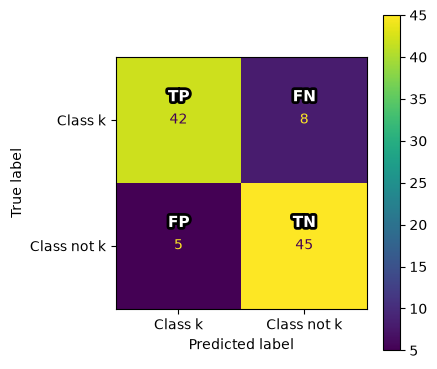

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.patheffects as pe

cm = np.array([[42,8],[5,45]])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Class k","Class not k"])

fig, ax = plt.subplots(figsize=(4.5,4))
disp.plot(ax=ax, colorbar=True)

cell_tags = np.array([["TP", "FN"], ["FP", "TN"]])

for i in range(2):
    for j in range(2):
        t = ax.text(j, i-0.18, cell_tags[i,j],
                ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")
        t.set_path_effects([pe.withStroke(linewidth=4, foreground="black")])

plt.tight_layout()
fig.savefig("Beispiel_cm.svg", transparent=True)